In [1]:
# Ruta del directorio actual
import os; ruta_actual = os.getcwd(); os.startfile(ruta_actual)

## MODELO DE FLUJO Y TRANSPORTE UTILIZANDO GWF y MT3D-USGS
## Modelación de las especies: sulfato $c_1= SO_4^{2-}$ y calcio $c_2 = Ca^{2+}$
### Flujo y transporte sin y con RCT en 1D utilizando GWF, MT3D-USGS y Flopy

$$\frac{\partial}{\partial x}( K \frac{\partial h }{\partial x})+ q_s = S_s \frac{\partial h }{\partial t} \tag{1} $$

$$\frac {\partial\left(\theta C^k\right)}{\partial t}  = \frac{\partial}{\partial x}\left(\theta D \frac{\partial C^k}{\partial x}\right)- \frac{\partial}{\partial x} (\theta v C^k) + q_s C^{k}_{s} \tag{2} $$


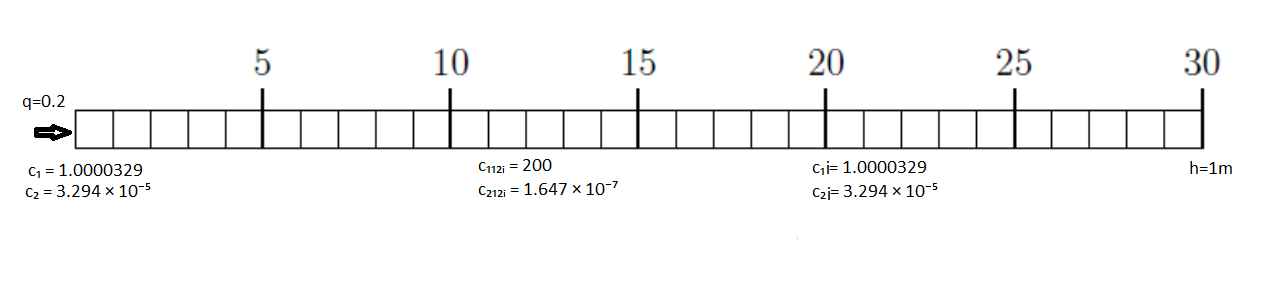

In [3]:
# insertar imagen incrustada en base64 dentro del notebook
from IPython.display import HTML
import base64
# Ruta de tu imagen
image_path = "dominio1.png"
# Leer imagen como base64
with open(image_path, "rb") as f:
    image_base64 = base64.b64encode(f.read()).decode("utf-8")
# HTML para incrustar la imagen
html = f'<img src="data:image/png;base64,{image_base64}" />'
# Mostrar imagen
HTML(html)

## DESCRIPCIÓN DEL MODELO GWF-MT3D-USGS
* **Problema de flujo 1D**
* con las siguientes dimensiones del dominio: 
* LX=30 m, LY=1 m, LZ=1 m
* considerando las siguientes condiciones de frontera:
* Flujo prescrito en la frontera izquierda CFI= 0.2 m3/d
* Carga prescrita en la frontera derecha CFD=1m  

* **Problema de transporte 1D**
* Se consideran dos especies con las siguientes condiciones de frontera y condiciones iniciales:
* **Especie 1: c1 (sulfato)**
* Concentración en el flujo de entrada: c₁ = 1.0000329
* Concentración inicial c1i = 1.0000329 en todo el dominio, excepto en la celda 12, donde c₁₁₂ᵢ = 200
* **Especie 2: c2 (calcio)**
* Concentración en el flujo de entrada: c₂ = 3.294 × 10⁻⁵
* Concentración inicial  c₂ᵢ: 3.294 × 10⁻⁵ en todo el dominio, excepto en la celda 12, donde c₂₁₂ᵢ = 1.647 × 10⁻⁷
* Estas concentraciones fueron calculadas usando la ley de acción de masas, con:
* c₂ᵢ = Kₑ / c₁ᵢ = 3.29382 × 10⁻⁵ / 1.0000329 = 3.294 × 10⁻⁵  
* c₂₁₂ᵢ = 3.29382 × 10⁻⁵ / 200 = 1.647 × 10⁻⁷

* **Las propiedades físicas del problema son**:
* Conductividad hidráulica = 1.0 m/día
* Porosidad = 0.5
* Dispersividad longitudinal =0.2
* Factor de retardación =1.0
* Se simulan 40 días en 40 pasos de tiempo


## 1. Preparación del entorno

In [6]:
# Preparación del entorno
import os, sys #Permite interactuar con el sistema operativo, y al intérprete de Python
import numpy as np #Proporciona estructuras y operaciones matemáticas de alto rendimiento.
import flopy
import matplotlib.pyplot as plt
from flopy.utils.binaryfile import HeadFile, CellBudgetFile, UcnFile
from flopy.plot.styles import styles
import pandas as pd # Facilita la manipulación y análisis de datos en estructuras tabulares.

# --- Definición de rutas ---
base_dir = os.getcwd()               # Directorio actual de trabajo
workspace = os.path.join(base_dir, "flow_transport")  # Carpeta para guardar archivos flow_transport
exe_dir = os.path.join(base_dir, "EXE")               # Carpeta con ejecutables
os.makedirs(workspace, exist_ok=True)                 # Crear "flow_transport" si no existe

# --- Ejecutables ---
mf6_exe = os.path.join(exe_dir, "mf6.exe")
mt3d_exe = os.path.join(exe_dir, "mt3d-usgs_1.1.0_64.exe")

# --- Nombres de los archivos del modelo  ---
sim_name = "flow_transport" # Nombre de la simulación
flow_name = "flow" # Nombre archivos de flujo
transport_name = "transport" # Nombre archivos de transporte
print(mf6_exe)

C:\Users\NRBRT\clone\WMACC\DESARROLLO_MODELOS\GWF-MT3D-USGS\R1-GWF-MT3D-USGS\VERSIONES-0\CICLO\EXE\mf6.exe


## 2. Construcción del modelo de flujo (MODFLOW 6)

In [8]:
# Se define la simulación MFSimulation con nombre, ruta de trabajo y ejecutable mf6.
sim = flopy.mf6.MFSimulation(sim_name=sim_name, sim_ws=workspace, exe_name=mf6_exe)

# Se configura el tiempo total de 40 días con 40 pasos de 1 día cada uno.
tdis = flopy.mf6.ModflowTdis(sim, time_units="days", perioddata=[(1.0, 1, 1.0)]) # (perlen,nstp,1.0)

# Se incluye un iterative model solution (ModflowIms) para resolver el modelo.
ims = flopy.mf6.ModflowIms(sim, pname="ims")

# Se crea el modelo de flujo subterráneo (GWF) asociado a la simulación.
gwf = flopy.mf6.ModflowGwf(sim, modelname=flow_name, save_flows=True)

# Se define una malla de 1 capa, 1 fila, 31 columnas, con celdas de 1 metro de tamaño.
dis = flopy.mf6.ModflowGwfdis(gwf, nlay=1, nrow=1, ncol=31, delr=1.0, delc=1.0, top=1.0, botm=[0.0])

# Se establece una carga inicial de 1.0 en toda la malla.
ic = flopy.mf6.ModflowGwfic(gwf, strt=1.0)

# Se asigna una conductividad hidráulica de 1.0 m/día y se activa el cálculo del flujo específico.
npf = flopy.mf6.ModflowGwfnpf(gwf, icelltype=0, k=1.0, save_flows=True, save_specific_discharge=True)

# Se impone una carga fija de 1.0 en la celda del extremo derecho (columna 30).
chd_spd = [[(0, 0, 30), 1.0]]
chd = flopy.mf6.ModflowGwfchd(gwf, stress_period_data=chd_spd)

# Se coloca un pozo en la columna 0 que inyecta agua con un caudal de 0.2 y concentraciones c1 y c2
c1 = 1.0000329 # sulfato
c2 = 3.294e-5  # calcio
wel_spd = [[(0, 0, 0), 0.2, c1, c2]]
wel = flopy.mf6.ModflowGwfwel(gwf, stress_period_data=wel_spd, auxiliary=["CONC_ESP_1", "CONC_ESP_2"])

# Se configuran archivos de salida para cargas (.hds) y balance (.bud), guardando e imprimiendo todo.
oc = flopy.mf6.ModflowGwfoc(
    gwf,
    head_filerecord=f"{flow_name}.hds",
    budget_filerecord=f"{flow_name}.bud",
    saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")],
    printrecord=[("HEAD", "ALL"), ("BUDGET", "ALL")]
)

# Se guardan todos los archivos necesarios para ejecutar la simulación en el directorio especificado.
sim.write_simulation()
print(f"Archivos de flujo escritos en {workspace}")

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims...
  writing model flow...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package npf...
    writing package chd_0...
INFORMATION: maxbound in ('gwf6', 'chd', 'dimensions') changed to 1 based on size of stress_period_data
    writing package wel_0...
INFORMATION: maxbound in ('gwf6', 'wel', 'dimensions') changed to 1 based on size of stress_period_data
    writing package oc...
Archivos de flujo escritos en C:\Users\NRBRT\clone\WMACC\DESARROLLO_MODELOS\GWF-MT3D-USGS\R1-GWF-MT3D-USGS\VERSIONES-0\CICLO\flow_transport


## XXXXXXXXXXXXXXXXXXXXXXXXXXXXX

# 6. **Inicia construcción del modelo de transporte (MT3D-USGS)**

## Definición de parámetros

In [12]:
### UNIDADES DEL MODELO
length_units = "meters"
time_units = "days"

### PARÁMETROS ESPACIALES Y TEMPORALES DEL MODELO
nper = 1          # Número de periodos de simulación.
nlay = 1          # Número de capas del modelo.
nrow = 1          # Número de filas.
ncol = 31         # Número de columnas.
delr = 1.0        # Tamaño de celda en la dirección x (columnas), en metros.
delc = 1.0        # Tamaño de celda en la dirección y (filas), en metros.
top = 1.0         # Elevación del tope del modelo (en metros).
botm = 0.0        # Elevación del fondo del modelo (en metros).
prsity = 0.5      # Porosidad efectiva del medio poroso.
perlen = 1       # Duración del periodo de simulación, en días.

### PROPIEDADES HIDRÁULICAS
k11 = 1.0         # Conductividad hidráulica horizontal (en m/d).
k33 = k11         # Conductividad hidráulica vertical, igual a la horizontal.
laytyp = 1        # Tipo de capa: 1 significa convertible (uso típico en flujo no confinado).

### TIEMPO Y MALLA HIDRÁULICA
nstp = 1         # (cambiar tdis): Número de pasos de tiempo por periodo.
dt0 = perlen / nstp  # Paso de tiempo inicial (1.0 día en este caso).
Lx = (ncol - 1) * delr  # Longitud total del modelo (en x), excluyendo la última columna.


## 7. Configura un modelo de transporte de contaminantes MT3D-USGS usando Flopy, especificando el nombre del modelo, la ubicación de los archivos, la versión del software y el ejecutable.
**(Selección de nombre, directorio de trabajo, versión, ejecutable y uso de formato libre FTL)**

In [14]:
# Crea la instancia *mt*
mt = flopy.mt3d.Mt3dms( # mt: Variable donde se almacena la instancia del modelo de transporte.
    modelname=transport_name, # Asigna el nombre base del modelo de transporte.
    modflowmodel=gwf,  # <--- Esto permite heredar valores como nlay, delr, etc.
    model_ws=workspace, # Define la carpeta de trabajo donde se guardan los archivos del modelo.
    version="mt3d-usgs", # Indica la versión de MT3D-USGS que se usará.
    namefile_ext="onam", # Establece la extensión del archivo principal del modelo
    exe_name=mt3d_exe,   #nombre o ruta del ejecutable de MT3D-USGS.
    ftlfree=True #Activa el formato libre para el archivo FTL (archivo de seguimiento de flujo).
)


## 8. Configura el paquete BTN (Basic Transport Package) para un modelo de transporte con MT3D-USGS en una malla de 1×1×31:
**(Parámetros básicos de transporte, discretización y concentraciones iniciales)**

## Configura el paquete BTN multicomponente para un modelo MT3D-USGS con 3 especies móviles (sulfato, calcio y calcita) en una malla 1×1×31.

In [17]:
# --- Dimensiones del dominio ---
nlay = 1
nrow = 1
ncol = 31
ncomp = 2  # Dos especies: sulfato y calcio
mcomp = 2  # Ambas son móviles

# Leer archivo plano y reformarlo
entrada = "conc_s.txt"
datos = np.fromfile(entrada, sep=" ")
sconc_sulfato = datos.reshape((1, 1, 31))
#print(sconc_sulfato)

# --- Concentraciones iniciales ---
#sconc_sulfato = np.ones((nlay, nrow, ncol), dtype=float) * 1.0000329   # sulfato
#sconc_sulfato[0, 0, 11] = 200.0         # sulfato másivo

sconc_calcio = np.ones((nlay, nrow, ncol), dtype=float) * 3.294e-5    # calcio
sconc_calcio[0, 0, 11] = 1.647e-7      # calcio reducido

# Pulso en columna 11 (índice 11) para cada especie

# --- Condiciones de frontera ---
icbund = np.ones((nlay, nrow, ncol), dtype=int)
icbund[:, 0, 0] = -1  # frontera izquierda

# --- Espesores ---
dz = np.ones((nlay, nrow, ncol), dtype=float) * 1.0

# --- Parámetros de tiempo ---
dt = perlen / nstp
timprs = [dt * (i + 1) for i in range(nstp)]
print("timprs ",timprs)

# --- Crear el paquete BTN ---
btn = flopy.mt3d.Mt3dBtn(
    model=mt,
    nlay=nlay,
    nrow=nrow,
    ncol=ncol,
    nper=nper,
    ncomp=ncomp,
    mcomp=mcomp,
    delr=1,
    delc=1,
    htop=1,
    dz=dz,
    perlen=perlen,
    nstp=nstp,
    dt0=dt0,
    tsmult=1,
    prsity=prsity,
    sconc=sconc_sulfato,     # especie 1: sulfato
    sconc2=sconc_calcio,    # especie 2: calcio
    unitnumber=31,
    ifmtcn=1,
    species_names=["SO4", "Ca"],
    savucn=True,
    nprs=-1,
    timprs=timprs,
    icbund=icbund,
    laycon=0
)


[[[ 0.96  0.96  0.96  0.96  0.96  0.96  0.96  1.04  1.92 10.39 64.49
   57.69 35.79 18.99  9.34  4.61  2.47  1.56  1.19  1.04  0.99  0.97
    0.96  0.96  0.96  0.96  0.96  0.96  0.96  0.96  0.96]]]
[1.0]


## 9. Configura el paquete de advección ADV en un modelo de transporte con MT3D-USGS usando FloPy.
**(Selección de esquema de advección, ajustes de estabilidad y otros parámetros de transporte)**

In [19]:
# --- Paquete de Advección (ADV) para múltiples especies: sulfato, calcio y calcita/yeso ---

mixelm = 0       # Método de diferencias finitas estándar (convencional)
percel = 0.5     # Fracción del tamaño de celda usada para controlar paso de tiempo
mxpart = 800000  # Número máximo de "partículas" rastreadas (si se usa método basado en partículas)
nadvfd = 1       # Esquema upstream weighting (ponderación hacia arriba)

adv = flopy.mt3d.Mt3dAdv(
    mt,
    mixelm=mixelm,
    percel=percel,
    mxpart=mxpart,
    nadvfd=nadvfd
)


## 10. Configura el paquete de dispersión DSP para MT3DMS con parámetros globales:
**(Parámetros de dispersión longitudinal, transversal y difusividad molecular)**

In [21]:
# --- Paquete de Dispersión (DSP) para dos especies: sulfato y calcio ---

al = 0.2        # Dispersividad longitudinal [m]
trpt = 0.1      # Relación transversal horizontal
trpv = 0.01     # Relación transversal vertical

# Coeficientes de difusión molecular [m²/s]
dmcoef  = 1.0e-9   # sulfato
dmcoef2 = 9.0e-8  # calcio

dsp = flopy.mt3d.Mt3dDsp(
    model=mt,
    al=al,
    trpt=trpt,
    trpv=trpv,
    dmcoef=dmcoef,
    dmcoef2=dmcoef2,
    multiDiff=True  # usar diferentes coeficientes para cada especie
)


## 11. Configura el paquete GCG (solucionador numérico) para MT3DMS usando FloPy
**(Ajustes numéricos para la resolución iterativa del transporte)**

In [23]:
# --- Paquete GCG (Generalized Conjugate Gradient) para dos especies: sulfato y calcio ---

mxiter = 10000   # Máx. número de iteraciones externas
iter1 = 50       # Máx. número de iteraciones internas por ciclo
isolve = 3       # Método de resolución: 3 = GCG
ncrs = 0         # Sin preacondicionador (0)
accl = 1.0       # Factor de aceleración
cclose = 1.0e-6  # Criterio de convergencia por componente
iprgcg = 1       # Mostrar progreso en consola (1 = sí)

gcg = flopy.mt3d.Mt3dGcg(
    model=mt,
    mxiter=mxiter,
    iter1=iter1,
    isolve=isolve,
    ncrs=ncrs,
    accl=accl,
    cclose=cclose,
    iprgcg=iprgcg
)


## 12. configura el paquete SSM (Source/Sink Mixing) de MT3D-USGS con FloPy
**(Asignación de flujos contaminantes, concentraciones en pozos, drenes u otras fuentes)**

In [25]:
# --- Configuración del paquete SSM para 2 especies: sulfato (0) y calcio (1) ---

itype = flopy.mt3d.Mt3dSsm.itype_dict()
dtype = flopy.mt3d.Mt3dSsm.get_default_dtype(ncomp=2)

flota_sulfato = 1.0000329
p_sulfato = 200.0

flota_calcio = 3.294e-5
p_calcio = 1.647e-7

ssm_data = {}

for per in range(nper):
    period_data = []

    # Frontera izquierda (entrada continua)
    period_data.append((0, 0, 0, flota_sulfato, itype["WEL"], 0, 0))  # sulfato
    period_data.append((0, 0, 0, flota_calcio,  itype["WEL"], 1, 0))  # calcio

    # Pulso en columna 11 (solo al inicio)
    if per == 0:
        period_data.append((0, 0, 11, p_sulfato, itype["WEL"], 0, 0))   # sulfato
        period_data.append((0, 0, 11, p_calcio, itype["WEL"], 1, 0))    # calcio

    ssm_data[per] = period_data

# Crear el paquete SSM sin errores de longitud de registro
ssm = flopy.mt3d.Mt3dSsm(
    model=mt,
    dtype=dtype,
    stress_period_data=ssm_data,
    mxss=300
)


## 13. Configura el paquete RCT (Reacciones químicas) en MT3D-USGS con:
* Adsorción lineal activada (isothm=1)
* Reacciones de primer orden en fases disuelta (rc1=0.002) y adsorbida (rc2=0.002)
* Sin reacciones avanzadas (ireaction=0, igetsc=0)
**(Parámetros de reacción y procesos de degradación o sorción en el transporte)**

In [27]:
# VERSIÓN ORIGINAL DE RCT
# Se configura el paquete de reacciones químicas **rct** 
isothm = 1 # se usará una isoterma de adsorción lineal.
ireact = 1 # se aplicarán reacciones de primer orden.
irctop = 2 # controla la lectura de los coeficientes de reacción.
igetsc = 0 # no se obtendrán concentraciones escalares adicionales
ireaction = 0 # 0=Deshabilita funciones de reacción complementarias.
rhob = 0.25 # Asigna la densidad aparente del suelo (para adsorción).
rc1 = 0.002  # Establece la tasa de reacción o decaimiento de primer orden en la fase disuelta.
rc2 = 0.004  # Define la tasa de reacción o decaimiento en la fase adsorbida.

rct = flopy.mt3d.Mt3dRct( #Crea y configura el paquete RCT para controlar reacciones químicas y procesos de adsorción en MT3D.
    mt, isothm=isothm, ireact=ireact, igetsc=igetsc, rhob = rhob, rc1=rc1, rc2=rc2
)

RCT: setting srconc for component 2 to zero, kwarg name srconc2
RCT: setting sp1 for component 2 to zero, kwarg name sp12
RCT: setting sp2 for component 2 to zero, kwarg name sp22
RCT: setting rc1 for component 2 to zero, kwarg name rc12
RCT: setting rc2 for component 2 to zero, kwarg name rc22


## 14. mt.write_input() Escribe los archivos de entrada para la simulación MT3D-USGS, usando la configuración definida en mt.
**(.btn, .adv, .dsp, .ssm, .rct, entre otros)**

In [29]:
# Se generan todos los archivos de entrada del modelo de transporte MT3D-USGS (.btn, .adv, .dsp, .ssm, .rct, etc.)
mt.write_input()

## 15. Ejecución del transporte

In [31]:
# SE DUPLICA mt PARA USAR .nam en lugar de .onam
mt = flopy.mt3d.Mt3dms( # mt: Variable donde se almacena la instancia del modelo de transporte.
    modelname=transport_name, # Asigna el nombre base del modelo de transporte.
    modflowmodel=gwf,  # <--- Esto permite heredar valores como nlay, delr, etc.
    model_ws=workspace, # Define la carpeta de trabajo donde se guardan los archivos del modelo.
    version="mt3d-usgs", # Indica la versión de MT3D-USGS que se usará.
    namefile_ext="nam", # Establece la extensión del archivo principal del modelo
    exe_name=mt3d_exe,   #nombre o ruta del ejecutable de MT3D-USGS.
    ftlfree=True #Activa el formato libre para el archivo FTL (archivo de seguimiento de flujo).
)


In [32]:
print(mt.exe_name)

success, _ = mt.run_model(silent=True)
#if success:
#    print("✅ Simulación de transporte ejecutada exitosamente.")
#else:
#    print("❌ Error en la simulación de transporte.")
#    #print(buff.decode())


C:\Users\NRBRT\clone\WMACC\DESARROLLO_MODELOS\GWF-MT3D-USGS\R1-GWF-MT3D-USGS\VERSIONES-0\CICLO\EXE\mt3d-usgs_1.1.0_64.exe


## 16. Visualización de concentraciones utilizando el archivo **(transport.m3d)**, CON RCT

In [34]:
# SCRIPT PARA GRAFICAR ESPECIES CON RCT
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Markdown
import warnings

def parse_m3d_ascii(filepath, ncol=31, ncol_celdas=32):
    with open(filepath, 'r') as f:
        lines = f.readlines()

    species_data = {}
    celdas_c_data = {}
    current_species = None
    current_time = None
    block_data = []

    for i, line in enumerate(lines):
        if "FOR COMPONENT NO." in line:
            match = re.search(r"FOR COMPONENT NO\.\s+(\d+)", line)
            if match:
                current_species = int(match.group(1)) - 1
                if current_species not in species_data:
                    species_data[current_species] = []
                    celdas_c_data[current_species] = []

        elif "TOTAL ELAPSED TIME SINCE BEGINNING OF SIMULATION" in line:
            time_match = re.search(r"=\s*([0-9.Ee+-]+)", line)
            if time_match:
                current_time = float(time_match.group(1))

        elif "CONCENTRATIONS" in line and current_species is not None:
            block_data = []
            for j in range(i + 2, i + 7):
                if j < len(lines):
                    block_data.append(lines[j].strip())

            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=DeprecationWarning)
                flat = np.fromstring(" ".join(block_data), sep=" ")

            if flat.size == ncol:
                arr = flat.reshape((1, 1, ncol))
                species_data[current_species].append((current_time, arr))


            celdas_c_lines = []
            for k in range(i + 7, i + 10):
                if k < len(lines):
                    celdas_c_lines.append(lines[k].strip())

            if len(celdas_c_lines) == 3:
                celdas_c_values = []
                for idx, celdas_c_line in enumerate(celdas_c_lines):
                    parts = re.split(r'\s+', celdas_c_line)
                    numeric_parts = [float(x) for x in parts if x]
                    if idx == 0:
                        celdas_c_values.extend(numeric_parts[1:])
                    else:
                        celdas_c_values.extend(numeric_parts)

                celdas_c_arr = np.array(celdas_c_values)
                if  celdas_c_arr.size == ncol: # Cambio a ncol
                    celdas_c_arr =  celdas_c_arr.reshape((1, 1, ncol))
                    celdas_c_data[current_species].append((current_time, celdas_c_arr))

    return species_data, celdas_c_data

def visualizar_concentracion_m3d_interactivo(filepath, layer_index=0, ncol=31, ncol_celdas=32):
    data, celdas_data = parse_m3d_ascii(filepath, ncol=ncol, ncol_celdas=ncol_celdas)


    especies = ["Sulfato con RCT (SO₄²⁻)", "Calcio con RCT(Ca²⁺)"]
    especie_selector = widgets.Dropdown(
        options=[(especies[i], i) for i in sorted(data.keys())],
        value=0,
        description='Especie:',
        layout=widgets.Layout(width="300px")
    )

    tiempos = sorted(list(set([t for sublist in data.values() for t, _ in sublist])))
    if not tiempos:
        return

    buttons = [
        widgets.ToggleButton(
            value=(t == tiempos[-1]),
            description=f"{t:.1f}",
            tooltip=str(t),
            layout=widgets.Layout(width="65px")
        )
        for t in tiempos
    ]
    button_box = widgets.HBox(buttons, layout=widgets.Layout(flex_flow='row wrap', flex_wrap='wrap'))
    output_plot = widgets.Output()
    output_values = widgets.Output()
    output_celdas_c = widgets.Output()

    def update_plot(change=None):
        selected_times = [float(btn.tooltip) for btn in buttons if btn.value]
        especie_idx = especie_selector.value



        with output_plot:
            output_plot.clear_output(wait=True)
            if not selected_times:
                return

            plt.figure(figsize=(12, 5))
            for t in selected_times:
                celdas_c_arr = next((arr for time, arr in celdas_data[especie_idx] if time == t), None)
                if celdas_c_arr is not None:
                    x = np.arange(celdas_c_arr.shape[-1])
                    mean_conc = np.nanmean(celdas_c_arr[layer_index], axis=0)
                    plt.plot(x, mean_conc, marker='o', label=f"t = {t:.1f} d")

            plt.xlabel("Columna")
            plt.ylabel("Concentración")
            plt.title(f"{especies[especie_idx]} – Capa {layer_index}")
            plt.grid(True, which='both', linestyle='--')
            plt.legend()
            plt.tight_layout()
            plt.show()

        with output_values:
            output_values.clear_output(wait=True)
            for t in selected_times:
                conc_arr = next((arr for time, arr in data[especie_idx] if time == t), None)
                if conc_arr is not None:
                    display(Markdown(f"### t = {t:.1f} d - Concentraciones"))

        with output_celdas_c:
            output_celdas_c.clear_output(wait=True)
            for t in selected_times:
                celdas_c_arr = next((arr for time, arr in celdas_data.get(especie_idx, []) if time == t), None)
                print(f"Para t={t}, especie={especie_idx}, \n celdas_c_arr: {celdas_c_arr}")

    for btn in buttons:
        btn.observe(update_plot, names='value')
    especie_selector.observe(update_plot, names='value')

    display(especie_selector, button_box, output_plot, output_values, output_celdas_c)
    update_plot()

# Ejecutar visualización desde transport.m3d
m3d_path = os.path.join("flow_transport", "transport.m3d")
visualizar_concentracion_m3d_interactivo(m3d_path, layer_index=0)

C:\Users\NRBRT\.conda\envs\flotest\lib\site-packages\traitlets\traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Layout).__init__(flex_wrap='wrap').
object.__init__() takes exactly one argument (the instance to initialize)
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Dropdown(description='Especie:', layout=Layout(width='300px'), options=(('Sulfato con RCT (SO₄²⁻)', 0), ('Calc…

Output()

Output()

Output()

## 17. PARA IMPRIMIR Y GUARDAR EN conc_i.m3d LOS VALORES DE LA ESPECIE=0¶
## conc_i.m3d es el resultado de la simulación GWF-MT3D

In [36]:
# Leer directamente el contenido de celdas_c_data desde el archivo
_, celdas_c_data = parse_m3d_ascii(m3d_path, ncol=31, ncol_celdas=32)

# Especie que se desea imprimir y guardar
especie = 0
output_file = "conc_i.m3d"

with open(output_file, "w", encoding="utf-8") as f:
    if especie in celdas_c_data:
        for tiempo, arreglo in celdas_c_data[especie]:
            # Encabezado de tiempo
            encabezado = f"# Tiempo = {tiempo} días"
            print("✅", encabezado)
            #f.write(encabezado + "\n")

            # Extraer arreglo plano (shape: (1,1,ncol)) -> (ncol,)
            plano = arreglo.flatten()

            # Imprimir y guardar los datos en ASCII plano
            print("✅ Se guardó la concentración resultante en: conc_i.m3d")

            for val in plano:
                linea = f"{val:.6e}"
                #print(linea)
                f.write(linea + "\n")
    else:
        mensaje = f"# No hay datos para la especie {especie}"
        print(mensaje)
        f.write(mensaje + "\n")

✅ # Tiempo = 1.0 días
✅ Se guardó la concentración resultante en: conc_i.m3d


## XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX